In [2]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 14.1 MB/s eta 0:00:00


In [3]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 21.4 MB/s eta 0:00:00


In [4]:
# import les packages
import numpy as np
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.model_selection import cross_val_score,KFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, accuracy_score, roc_auc_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.pipeline import make_pipeline
import re
import requests
from bs4 import BeautifulSoup
import emoji
from joblib import Memory
import matplotlib.pyplot as plt
import spacy
import optuna
import json

In [5]:
import warnings
warnings.filterwarnings("ignore",category=UserWarning)

# I. Preprocessing Data

In [6]:
# Open the JSON file and return the data as a DATAFRAME
path='/Users/gonondozoua/Downloads/EXIST2021-2024_datasets'

def read_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return pd.DataFrame(data).T

In [7]:
df=read_json_file('EXIST2024_training.json')
df.head()

,id_EXIST,lang,tweet,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,labels_task1,labels_task2,labels_task3,split
100001,100001,es,"@TheChiflis Ignora al otro, es un capullo.El p...",6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, High sc...","[Italy, Mexico, United States, Spain, Spain, C...","[YES, YES, NO, YES, YES, YES]","[REPORTED, JUDGEMENTAL, -, REPORTED, JUDGEMENT...","[[OBJECTIFICATION], [OBJECTIFICATION, SEXUAL-V...",TRAIN_ES
100002,100002,es,@ultimonomada_ Si comicsgate se parece en algo...,6,"[Annotator_7, Annotator_8, Annotator_9, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Black or African American, Hispano or Latino,...","[High school degree or equivalent, Bachelor’s ...","[United Kingdom, Mexico, United States, Portug...","[NO, NO, NO, NO, YES, NO]","[-, -, -, -, DIRECT, -]","[[-], [-], [-], [-], [OBJECTIFICATION], [-]]",TRAIN_ES
100003,100003,es,"@Steven2897 Lee sobre Gamergate, y como eso ha...",6,"[Annotator_7, Annotator_8, Annotator_9, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Black or African American, Hispano or Latino,...","[High school degree or equivalent, Bachelor’s ...","[United Kingdom, Mexico, United States, Portug...","[NO, NO, NO, NO, NO, NO]","[-, -, -, -, -, -]","[[-], [-], [-], [-], [-], [-]]",TRAIN_ES
100004,100004,es,@Lunariita7 Un retraso social bastante lamenta...,6,"[Annotator_13, Annotator_14, Annotator_15, Ann...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Hispano or Latino, Hispano or Latino, White o...","[High school degree or equivalent, Bachelor’s ...","[Mexico, Chile, Spain, Spain, Portugal, Spain]","[NO, NO, YES, NO, YES, YES]","[-, -, DIRECT, -, REPORTED, REPORTED]","[[-], [-], [IDEOLOGICAL-INEQUALITY], [-], [IDE...",TRAIN_ES
100005,100005,es,@novadragon21 @icep4ck @TvDannyZ Entonces como...,6,"[Annotator_19, Annotator_20, Annotator_21, Ann...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Hispano or Latino, Hispano or Latino, White o...","[Bachelor’s degree, Bachelor’s degree, Master’...","[Mexico, Afghanistan, United States, Italy, Po...","[YES, NO, YES, NO, YES, YES]","[REPORTED, -, JUDGEMENTAL, -, JUDGEMENTAL, DIR...","[[STEREOTYPING-DOMINANCE, OBJECTIFICATION], [-...",TRAIN_ES


In [8]:
def count(x):
    c=0
    for word in x:
        if word=='YES':
            c+=1
    return c
df['sexism']=df.labels_task1.apply(lambda x:count(x)) # number of annotators that identifies sexism
df['label']=df['sexism'].apply(lambda x: 1 if x>=3 else 0)
df=df[['tweet','label','lang']]

In [9]:
df_1=read_json_file('EXIST2023_dev.json')
df_2=pd.read_csv('EXIST2021_training.tsv',delimiter='\t')
df_1['label']=df_1.labels_task1.apply(lambda x:count(x)).apply(lambda x: 1 if x>=3 else 0)
df_1=df_1[['tweet','label','lang']]
df_2=df_2[['text','task1','language']].rename( {'text':'tweet','task1':'label',
                                                'language':'lang'},axis=1)
df_2['label']=df_2['label'].apply(lambda x: 1 if x=='sexist' else 0)
df=pd.concat([df,df_1,df_2],ignore_index=True)
df

,tweet,label,lang
0,"@TheChiflis Ignora al otro, es un capullo.El p...",1,es
1,@ultimonomada_ Si comicsgate se parece en algo...,0,es
2,"@Steven2897 Lee sobre Gamergate, y como eso ha...",0,es
3,@Lunariita7 Un retraso social bastante lamenta...,1,es
4,@novadragon21 @icep4ck @TvDannyZ Entonces como...,1,es
...,...,...,...
14930,"Estamos igual sin pareja, pero puedes besar a ...",0,es
14931,2020 hijo de re mil putas,0,es
14932,SEGURAMENTE ESTA CHICA NO COBRA EL DINERO QUE ...,0,es
14933,@safetyaitana mi madre dice q va fea y i agree,1,es


In [16]:
df.describe()

,label
count,14935.000000
mean,0.501440
std,0.500015
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [10]:
def contains_url_or_emoji(text):
    # Check if the text contains a URL
    url_pattern = r'http[s]?://\S+'  # URL pattern
    contains_url = bool(re.search(url_pattern, text))

    # Check if the text contains any emoji
    contains_emoji = emoji.emoji_count(text) > 0  # Using emoji.emoji_count to check for emojis
    return contains_url or contains_emoji  # Return True if either URL or emoji is found

# Function to count the number of tweets that contain a URL or emoji
def count_tweets_with_url_or_emoji(df, column_name):
    count = df[column_name].apply(contains_url_or_emoji).sum()
    return count

In [11]:
count_tweets_with_url_or_emoji(df,'tweet')/len(df)

np.float64(0.3492467358553733)

<blockquote style="border-left: 4px solid #8e44ad; padding-left: 15px; font-style: italic; color: #8e44ad; background-color: #f9f9f9; border-radius: 5px;">
35% of the data contain either emoji or url.

Now we will preprocess the tweet
</blockquote>


In [12]:
def get_url_title(url):
    try:
        response = requests.get(url)
        soup = BeautifulSoup(response.text, 'html.parser')
        title = soup.title.string
        return title
    except:
        return "URL_ERROR"

# Function to clean and preprocess tweets
def process_url_tweet(text):
    # Replace URLs with their titles
    urls = re.findall(r'http[s]?://\S+', text)
    for url in urls:
        title = get_url_title(url)  # Fetch title for the URL
        if title is None or title == "URL_ERROR" or title == "No Title Found":
            text = text.replace(url, "")  # Remove the URL if title fetching failed
        else:

            text = text.replace(url, title)  # Replace URL with title

    return text


def preprocess_tweet(text):

    # 1. Remove URLs or Replace it by the Title
    #text = process_url_tweet(text)
    text = re.sub(r'http[s]?://\S+', '', text)

    # 2. Remove user tags (@username)
    text = re.sub(r'@\w+', '', text)

    # 3. Handle the emojis
    text=emoji.demojize(text)

    # 4. Remove numbers and standalone dates
    text = re.sub(r'\b\d{1,4}[-/]\d{1,2}[-/]\d{1,4}\b', '', text)  # dates like 2023-01-01
    text = re.sub(r'\b\d+\b', '', text)

    # 5. Remove inverted Spanish punctuation (¡ and ¿)
    text = re.sub(r'[¡¿]', '', text)

    # 6. Fix missing space after punctuation (e.g., "hello.This" → "hello. This")
    text = re.sub(r'([.!?])([^\s])', r'\1 \2', text)

    # 7. Normalize repeated punctuation: !!??!? → !!
    text = re.sub(r'([!?]){2,}', r'\1\1', text)
    text = re.sub(r'(!\?|\?!)+', '!?', text)

    # 8. Normalize repeated letters (e.g., soooo → soo)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 9. Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # 10. Strip leading/trailing spaces
    text = text.strip()

    # 11. Remove any slash followed by alphanumeric characters or symbols
    text = re.sub(r"\/", "", text)

    return text.strip() # Strip any leading/trailing spaces that may remain

In [13]:
df['tweet']=df['tweet'].apply(lambda x:preprocess_tweet(x))
df.head()

,tweet,label,lang
0,"Ignora al otro, es un capullo. El problema con...",1,es
1,Si comicsgate se parece en algo a gamergate pu...,0,es
2,"Lee sobre Gamergate, y como eso ha cambiado la...",0,es
3,"Un retraso social bastante lamentable, gamerga...",1,es
4,Entonces como así es el mercado lo mejor no es...,1,es


In [14]:
#split the english and spanish tweets
df_es=df[df['lang']=='es']
df_en=df[df['lang']=='en']
df_en.head()

,tweet,label,lang
3660,FFS! How about laying the blame on the bastard...,1,en
3661,Writing a uni essay in my local pub with a cof...,1,en
3662,it is not . I dont appreciate that on two ride...,1,en
3663,this is unacceptable. Use her title as you did...,1,en
3664,‘Making yourself a harder target’ basically bo...,1,en


In [15]:
print("Proportion of English tweets",len(df_en)/len(df))
print("Proportion of Spanish tweets",len(df_es)/len(df))

Proportion of English tweets 0.48108470036826245
Proportion of Spanish tweets 0.5189152996317375


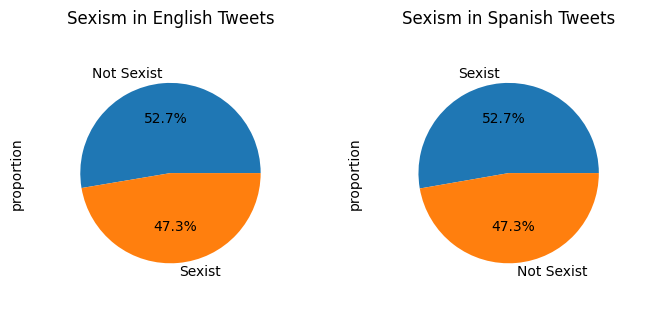

In [16]:
fig,ax=plt.subplots(1,2,figsize=(8, 8))
df_en['label'].value_counts(normalize=True).plot(kind='pie',autopct='%1.1f%%',labels=['Not Sexist','Sexist'],radius=0.8,ax=ax[0])
df_es['label'].value_counts(normalize=True).plot(kind='pie',autopct='%1.1f%%',labels=['Sexist','Not Sexist'],radius=0.8,ax=ax[1])
ax[0].set_title('Sexism in English Tweets', fontsize=12)
ax[1].set_title('Sexism in Spanish Tweets', fontsize=12)
plt.show()

In [17]:
pip install wordCloud

In [18]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS

def plot_word(df):
    """
    Function to plot wordcloud
    """
    # Wordcloud with positive tweets
    positive_tweets = df['tweet'][df["label"] == 0] # no sexism
    stop_words = ["https", "co", "RT"] + list(STOPWORDS)
    positive_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(positive_tweets))
    plt.figure()
    plt.title("Non sexist Tweets - Wordcloud")
    plt.imshow(positive_wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

    # Wordcloud with negative tweets
    negative_tweets = df['tweet'][df["label"] == 1] # sexism
    stop_words = ["https", "co", "RT"] + list(STOPWORDS)
    negative_wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white", stopwords = stop_words).generate(str(negative_tweets))
    plt.figure()
    plt.title("Sexist Tweets - Wordcloud")
    plt.imshow(negative_wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()


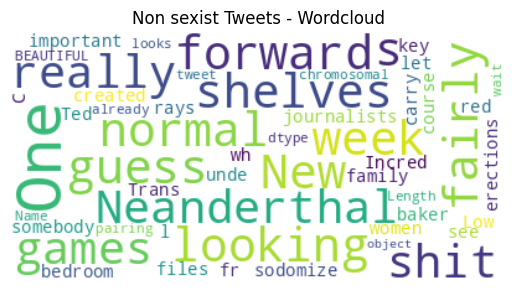

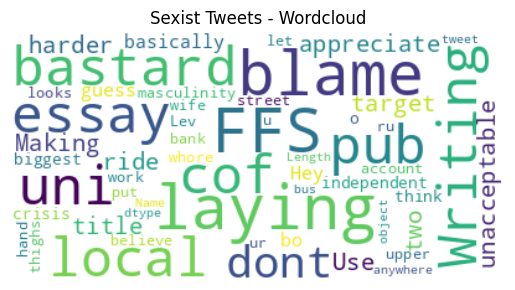

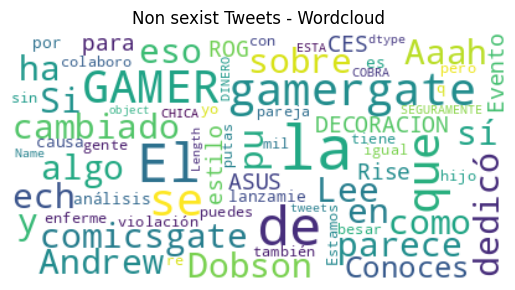

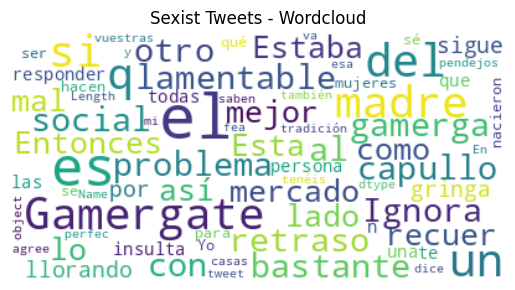

In [19]:
plot_word(df_en)
plot_word(df_es)

1. Machine Learning Models

In [ ]:
!python -m spacy download es_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 76.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp_en = spacy.load("en_core_web_sm")
nlp_es = spacy.load("es_core_news_sm")

def lemmatize_tweet(text,lang):
    # Function to lemmatize the tweet text
    if lang=='en':
        doc = nlp_en(text)
        return " ".join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct])
    else:
        doc = nlp_es(text)
        return " ".join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct])


text_en=df_en['tweet'].apply(lambda x: lemmatize_tweet(x,'en'))
text_es=df_es['tweet'].apply(lambda x: lemmatize_tweet(x,'es'))

In [ ]:
X_train_en,X_test_en,Y_train_en,Y_test_en=train_test_split(text_en,df_en['label'],stratify=df_en['label'],
                                                           test_size=0.2,random_state=42)
X_train_es,X_test_es,Y_train_es,Y_test_es=train_test_split(text_es,df_es['label'],stratify=df_es['label'],
                                                           test_size=0.2,random_state=42)

In [ ]:
# Initialize the TF-IDF Vectorizer
def create_tfidf_vectorizer(text,lang):
    tfidf_vectorizer =TfidfVectorizer()
    tfidf_matrix = tfidf_vectorizer.fit_transform(text)
    return tfidf_matrix.toarray(),tfidf_vectorizer

# Fit and transform the corpus
x_train_en,tfidf_en=create_tfidf_vectorizer(X_train_en,'en')
x_train_es,tfidf_es=create_tfidf_vectorizer(X_train_es,'es')
x_test_en=tfidf_en.transform(X_test_en).toarray()
x_test_es=tfidf_es.transform(X_test_es).toarray()

In [ ]:
print(x_train_en.shape,x_train_es.shape)

(5748, 12997) (6200, 17209)


In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca_en = pca.fit_transform(X_train_en-X_train_en.mean(axis=0))

# Step 4: Explained variance ratio (percentage of variance explained by each principal component)
explained_variance_ratio = pca.explained_variance_ratio_


# Step 6: Choose how many components to keep (e.g., keep 95% of the variance)
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components = np.where(cumulative_variance >= 0.8)[0][0] + 1  # Components to retain 95% variance
print(f"Number of components to keep for 80% variance: {n_components}")

pca = PCA(n_components=n_components)
X_pca_reduced = pca.fit_transform(X_train_en-X_train_en.mean(axis=0))

TypeError: Could not convert string 'go forth let slap okay imma pull hair hard go bald foreversay look like fucking serial killer think noncey cunt way greatSuika get gangbange deathwish happy woman daymuseum unapologetically devote consciousness raising raised_fist Great review Radical Landscapes exhibition Laura Cumming Observerbully use sexual orientation insult say think gay insult reason wrong gay say insult think gay bad thingmom show grandma video project media class family say cry watchatleast live Ireland guy look like arse look like arseobviously get sexual identity issue face_with_tears_of_joy try partner face_with_tears_of_joy surprise see get left wing Labour cnut write profile mind go to box face_with_tears_of_joy toodle halfwit smiling_face_with_smiling_eyes soonquote Day Feminine Mystique Betty Friedanyes phallogocentrism construction whitesupremacistcisnormativepatriarchytake compromise people right take money respect individual take political deal people freedom take

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Objective function for Logistic Regression
def study_logregression(X_train,Y_train):
    # Get the best parameters and AUC score for each model
    def objective_logreg(trial):
        C = trial.suggest_loguniform('C', 0.1,2)
        class_weight = trial.suggest_categorical('class_weight', ['balanced'])
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

        model = LogisticRegression(C=C, solver='liblinear', class_weight=class_weight,
                                fit_intercept=True, penalty=penalty, max_iter=100, random_state=42)

        # Perform cross-validation and return the mean AUC score
        auc_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='roc_auc')
        return auc_scores.mean()
    study_logreg = optuna.create_study(direction='maximize')
    study_logreg.optimize(objective_logreg, n_trials=50)
    return study_logreg.best_params, study_logreg.best_value


# Objective function for Naive Bayes
def study_naive_bayes(X_train,Y_train):
    def objective_nb(trial):
        var_smoothing = trial.suggest_loguniform('var_smoothing', 1, 20)

        model = GaussianNB(var_smoothing=var_smoothing)

        # Perform cross-validation and return the mean AUC score
        auc_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='roc_auc')
        return auc_scores.mean()
    study_NB = optuna.create_study(direction='maximize')
    study_NB.optimize(objective_nb, n_trials=50)
    return study_NB.best_params, study_NB.best_value



# Objective function for XGBoost
def study_xgboost(X_train,Y_train):
    def objective_xgboost(trial):
        learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2)
        max_depth = trial.suggest_int('max_depth', 3, 10)
        subsample = trial.suggest_float('subsample', 0.7, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.7, 1.0)
        reg_alpha = trial.suggest_float("reg_alpha", 0, 1.0)
        reg_lambda = trial.suggest_float("reg_lambda", 0, 1.0)

        model = xgb.XGBClassifier(learning_rate=learning_rate, max_depth=max_depth, n_estimators=50, subsample=subsample,
                                colsample_bytree=colsample_bytree, use_label_encoder=False,
                                reg_alpha=reg_alpha, reg_lambda=reg_lambda, eval_metric="mlogloss", objective="binary:logistic")

        # Perform cross-validation and return the mean AUC score
        auc_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='roc_auc')
        return auc_scores.mean()
    study_xgb=optuna.create_study(direction='maximize')
    study_xgb.optimize(objective_xgboost, n_trials=50)
    return study_xgb.best_params, study_xgb.best_value

# Objective function for SVM
def study_svm(X_train,Y_train):
    def objective_svm(trial):
        # Suggest hyperparameters for SVM
        kernel = trial.suggest_categorical('kernel', ['linear', 'poly'])
        C = trial.suggest_loguniform('C', 1, 100)  # Regularization parameter (log scale)
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto']) if kernel != 'linear' else 'auto'

        # Correctly handle degree and coef0 for different kernels:
        degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3  # Default value for other kernels
        coef0 = trial.suggest_float('coef0', 0.0, 10.0) if kernel in ['poly', 'sigmoid'] else 0.0

        model = SVC(C=C, kernel=kernel, gamma=gamma, degree=degree, coef0=coef0, probability=True, random_state=42)

        # Perform cross-validation and return the mean AUC score
        auc_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='roc_auc')
        return auc_scores.mean()
    study_svm=optuna.create_study(direction='maximize')
    study_svm.optimize(objective_svm, n_trials=25)
    return study_svm.best_params, study_svm.best_value

In [ ]:
study_logregression(x_train_en,Y_train_en)

In [ ]:
study_xgboost(X_pca_reduced,Y_train_en)

[I 2025-05-02 19:09:26,112] A new study created in memory with name: no-name-536e53e9-9d19-4313-b0cf-720366ca96ec
[I 2025-05-02 19:10:46,068] Trial 0 finished with value: 0.724073527045492 and parameters: {'learning_rate': 0.10601051457816145, 'max_depth': 8, 'subsample': 0.8584409349549469, 'colsample_bytree': 0.8284260117913926, 'reg_alpha': 0.9111690455447018, 'reg_lambda': 0.6435228703953287}. Best is trial 0 with value: 0.724073527045492.
[I 2025-05-02 19:13:29,730] Trial 1 finished with value: 0.7273064269128294 and parameters: {'learning_rate': 0.13219781700892275, 'max_depth': 10, 'subsample': 0.9647309703955522, 'colsample_bytree': 0.9109118675951635, 'reg_alpha': 0.9577872651961593, 'reg_lambda': 0.5879010186434087}. Best is trial 1 with value: 0.7273064269128294.
[I 2025-05-02 19:14:34,890] Trial 2 finished with value: 0.7244290226827215 and parameters: {'learning_rate': 0.11699463033480752, 'max_depth': 8, 'subsample': 0.7798777262918979, 'colsample_bytree': 0.8770801733602

({'learning_rate': 0.050096019399344466,
  'max_depth': 4,
  'subsample': 0.7208180094726243,
  'colsample_bytree': 0.7211611668848398,
  'reg_alpha': 0.7786246226708344,
  'reg_lambda': 0.9489163936513243},
 0.7456854707891976)

In [ ]:
study_svm(X_pca_reduced,Y_train_en)

[I 2025-05-02 19:56:51,590] A new study created in memory with name: no-name-c4d58e56-4054-4548-866a-16674df03f58
/var/folders/6q/8wd3xk4940sgv0pnnmb9bdwc0000gn/T/ipykernel_53075/1361767347.py:70: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 1, 100)  # Regularization parameter (log scale)
[I 2025-05-02 19:59:34,791] Trial 0 finished with value: 0.6893750105607692 and parameters: {'kernel': 'linear', 'C': 2.335961762049774}. Best is trial 0 with value: 0.6893750105607692.
/var/folders/6q/8wd3xk4940sgv0pnnmb9bdwc0000gn/T/ipykernel_53075/1361767347.py:70: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 1, 1

({'kernel': 'poly',
  'C': 6.868748082209053,
  'gamma': 'auto',
  'degree': 3,
  'coef0': 5.364226937098277},
 0.7507203805802518)

In [ ]:
models={
    'Logistic Regression': LogisticRegression( C=0.75, solver='liblinear', class_weight='balanced',
                               fit_intercept=True, penalty='l1',
                              max_iter=100, random_state=42),

    'Naive Bayes': GaussianNB(var_smoothing=10),

    'XGBoost': xgb.XGBClassifier(max_depth=5,learning_rate=0.05, subsample = 0.8,
                colsample_bytree=0.8, reg_alpha=0.85, reg_lambda=0.25, n_estimators=50,
                use_label_encoder=False, eval_metric='mlogloss', objective='binary:logistic'),

    'SVM': SVC(C=7,kernel='poly',gamma='auto',degree=3,coef0=5,probability=True)
    }

def evaluate_models(X_train, Y_train, X_test, Y_test,model):
    """
    Function to evaluate the models
    """
    # Fit the model
    model.fit(X_train, Y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate accuracy and F1 score
    accuracy = accuracy_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    return accuracy, f1

<blockquote style="border-left: 4px solid #8e44ad; padding-left: 15px; font-style: italic; color: #8e44ad; background-color: #f9f9f9; border-radius: 5px;">
Apply the models to the Test Dataset
</blockquote>


In [ ]:
for model in models.keys():
    accuracy, f1 = evaluate_models(x_train_en, Y_train_en, x_test_en, Y_test_en, models[model])
    print(f"{model} - Accuracy English: {accuracy:.4f}, F1 Score: {f1:.4f}")
    accuracy, f1 = evaluate_models(x_train_es, Y_train_es, x_test_es, Y_test_es, models[model])
    print(f"{model} - Accuracy Spanish: {accuracy:.4f}, F1 Score: {f1:.4f}")


Logistic Regression - Accuracy English: 0.7509, F1 Score: 0.7421
Logistic Regression - Accuracy Spanish: 0.7039, F1 Score: 0.7067
Naive Bayes - Accuracy English: 0.7279, F1 Score: 0.7245
Naive Bayes - Accuracy Spanish: 0.5335, F1 Score: 0.6917
XGBoost - Accuracy English: 0.7196, F1 Score: 0.6883
XGBoost - Accuracy Spanish: 0.6781, F1 Score: 0.6745
SVM - Accuracy English: 0.5595, F1 Score: 0.1660
SVM - Accuracy Spanish: 0.5271, F1 Score: 0.6903


## Transformers Based models:

In [24]:
import torch
from transformers import BertForSequenceClassification, BertTokenizer, Trainer, TrainingArguments
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a dataset class
class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])  # Don't move to device here
        return item

    def __len__(self):
        return len(self.labels)

def train_bert(X_train, Y_train, X_test, Y_test,lang):
    """
    Train the BERT model
    """
    if lang=='en':
      model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
      tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    else:
      tokenizer = BertTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-uncased')
      model = BertForSequenceClassification.from_pretrained('dccuchile/bert-base-spanish-wwm-uncased', num_labels=2)

    # Tokenize input data
    train_encodings = tokenizer(X_train.tolist(), return_tensors="pt", truncation=True, padding=True)
    train_labels = torch.tensor(Y_train.tolist())
    test_encodings = tokenizer(X_test.tolist(), return_tensors="pt", truncation=True, padding=True)
    test_labels = torch.tensor(Y_test.tolist())

    # Create datasets
    train_dataset = TweetDataset(train_encodings, train_labels)
    test_dataset = TweetDataset(test_encodings, test_labels)

    # Move model to the device (GPU/CPU)
    model.to(device)

    # Define training arguments
    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        weight_decay=0.01,
        save_strategy="epoch",
        output_dir="./results",
        eval_steps=100,
    )

    # Create trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
    )

    trainer.train()
    return trainer, test_dataset

def evaluate_bert(trainer, test_dataset):
    """
    Evaluate the BERT model
    """
    # Make predictions
    predictions = trainer.predict(test_dataset)

    # Extract logits and convert to predicted class (0 or 1)
    logits = predictions.predictions
    predicted_labels = np.argmax(logits, axis=1)

    # Get true labels
    true_labels = predictions.label_ids

    return predicted_labels, true_labels


# During training or evaluation, ensure that inputs are moved to the correct device
def collate_fn(batch):
    # Move tensors to device inside the collate_fn for batches during training/evaluation
    inputs = {key: torch.stack([x[key] for x in batch]).to(device) for key in batch[0].keys()}
    return inputs



In [22]:
x_train_es,x_test_es,y_train_es,y_test_es=train_test_split(df_es['tweet'],df_es['label'],stratify=df_es['label'],
                                                           test_size=0.2,random_state=42)
x_train_en,x_test_en,y_train_en,y_test_en=train_test_split(df_en['tweet'],df_en['label'],stratify=df_en['label'],
                                                           test_size=0.2,random_state=42)

In [ ]:
trainer_en,test_dataset_en=train_bert(x_train_en,y_train_en,x_test_en,y_test_en,"en")
predicted_labels_en,true_labels_en=evaluate_bert(trainer_en,test_dataset_en)
print(classification_report(true_labels_en,predicted_labels_en,target_names=["non-sexist", "sexist"]))
print("f1_score English",f1_score(true_labels_en, predicted_labels_en))
print("accuracy English",accuracy_score(true_labels_en, predicted_labels_en))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
500,0.557600
1000,0.443700
1500,0.362300
2000,0.221200


              precision    recall  f1-score   support

  non-sexist       0.85      0.75      0.80       757
      sexist       0.75      0.85      0.80       680

    accuracy                           0.80      1437
   macro avg       0.80      0.80      0.80      1437
weighted avg       0.80      0.80      0.80      1437

f1_score English 0.7977839335180056
accuracy English 0.7967988865692415


In [23]:
trainer_es,test_dataset_es=train_bert(x_train_es,y_train_es,x_test_es,y_test_es,"en")
predicted_labels_es,true_labels_es=evaluate_bert(trainer_es,test_dataset_es)
print(classification_report(true_labels_es,predicted_labels_es,target_names=["non-sexist", "sexist"]))
print("f1_score Spanish",f1_score(true_labels_es, predicted_labels_es))
print("accuracy Spanish",accuracy_score(true_labels_es, predicted_labels_es))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yannickgonondo (yannickgonondo-ensae-alumni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss


              precision    recall  f1-score   support

  non-sexist       0.55      0.12      0.19       733
      sexist       0.54      0.92      0.68       817

    accuracy                           0.54      1550
   macro avg       0.55      0.52      0.44      1550
weighted avg       0.55      0.54      0.45      1550

f1_score Spanish 0.6763110307414105
accuracy Spanish 0.5380645161290323


In [ ]:
trainer_es,test_dataset_es=train_bert(x_train_es,y_train_es,x_test_es,y_test_es,"es")
predicted_labels_es,true_labels_es=evaluate_bert(trainer_es,test_dataset_es)
print(classification_report(true_labels_es,predicted_labels_es,target_names=["non-sexist", "sexist"]))
print("f1_score Spanish",f1_score(true_labels_es, predicted_labels_es))
print("accuracy Spanish",accuracy_score(true_labels_es, predicted_labels_es))

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Step,Training Loss
500,0.596000
1000,0.457400
1500,0.386800
2000,0.222600


              precision    recall  f1-score   support

  non-sexist       0.76      0.72      0.74       733
      sexist       0.76      0.79      0.78       817

    accuracy                           0.76      1550
   macro avg       0.76      0.76      0.76      1550
weighted avg       0.76      0.76      0.76      1550

f1_score Spanish 0.7765128819652487
accuracy Spanish 0.7593548387096775


In [58]:
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification, Trainer, TrainingArguments
import torch
import torch.nn as nn
from torch.utils.data import Dataset

# Check if CUDA is available, otherwise default to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class XLMRobertaWithGELUClassification(nn.Module):
    def __init__(self, num_labels=2):
        """
        Initialize the XLM-RoBERTa model with GELU activation layers and a classification head.

        Args:
        num_labels (int): Number of classification labels (default is 2).
        """
        super(XLMRobertaWithGELUClassification, self).__init__()
        self.num_labels = num_labels  # Store number of labels for later use

        # Load pre-trained XLM-RoBERTa model with sequence classification head
        self.xlm_roberta = XLMRobertaForSequenceClassification.from_pretrained(
            'xlm-roberta-base',
            num_labels=num_labels,
            output_hidden_states=True  # Make sure hidden states are returned
        )

        # GELU activation layers
        self.gelu1 = nn.GELU()
        self.gelu2 = nn.GELU()

        # Classification head (Linear layer)
        self.classifier = nn.Linear(self.xlm_roberta.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        """
        Forward pass through the XLM-RoBERTa model with GELU activation layers and classification head.

        Args:
        input_ids (Tensor): Input token IDs.
        attention_mask (Tensor): Attention mask.
        labels (Tensor, optional): Ground truth labels for computing the loss.

        Returns:
        dict: A dictionary containing the logits and optionally the loss if labels are provided.
        """
        # Get the output of the XLM-RoBERTa model
        xlm_output = self.xlm_roberta(input_ids=input_ids, attention_mask=attention_mask)

        # Access hidden states (last layer is the most relevant)
        hidden_states = xlm_output.hidden_states
        if hidden_states is None:
            raise ValueError("hidden_states is None, check the model configuration.")

        # Get the [CLS] token representation from the last hidden layer
        pooled_output = hidden_states[-1][:, 0, :]

        # Apply GELU activation layers
        x = self.gelu1(pooled_output)
        x = self.gelu2(x)

        # Apply classification head to get logits
        logits = self.classifier(x)

        output = {'logits': logits}

        # If labels are provided, compute the loss
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
            output['loss'] = loss  # Add loss to output

        return output


class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        """
        Dataset class to process text data for the XLM-RoBERTa model.

        Args:
        texts (list): List of text samples.
        labels (list): List of labels corresponding to the text samples.
        tokenizer (PreTrainedTokenizer): Tokenizer to convert text to token IDs.
        max_length (int): Maximum length of input sequences after padding/truncation.
        """
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the input text
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')

        # Return the encoded input and label
        return {
            'input_ids': encoding['input_ids'].squeeze(0),  # Remove the batch dimension
            'attention_mask': encoding['attention_mask'].squeeze(0),  # Remove the batch dimension
            'labels': torch.tensor(label, dtype=torch.long)
        }


def train_roberta(X_train, Y_train, X_test, Y_test):
    """
    Train the XLM-RoBERTa model on the provided training data.

    Args:
    X_train (pd.Series or list): Training texts.
    Y_train (pd.Series or list): Training labels.
    X_test (pd.Series or list): Test texts.
    Y_test (pd.Series or list): Test labels.

    Returns:
    trainer (Trainer): The trained Trainer object.
    test_dataset (Dataset): The test dataset used for evaluation.
    """
    # Initialize tokenizer and datasets
    tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
    train_dataset = TextDataset(X_train, Y_train, tokenizer)
    test_dataset = TextDataset(X_test, Y_test, tokenizer)

    # Instantiate the model
    model = XLMRobertaWithGELUClassification(num_labels=2).to(device)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        weight_decay=0.01,
        logging_dir='./logs',
    )

    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        tokenizer=tokenizer,
    )

    # Train the model
    trainer.train()

    return trainer, test_dataset

def evaluate_roberta(trainer, test_dataset):
    """
    Evaluate the trained model on the test dataset.

    Args:
    trainer (Trainer): The trained Trainer object.
    test_dataset (Dataset): The test dataset for evaluation.

    Returns:
    predicted_labels (np.ndarray): The predicted labels for the test dataset.
    true_labels (np.ndarray): The true labels for the test dataset.
    """
    predictions, true_labels, _ = trainer.predict(test_dataset)

    # Get predicted probabilities from the logits
    predicted_labels = np.argmax(predictions,axis=1)

    # No need to call .cpu() on true_labels since it's already a NumPy array
    true_labels = true_labels

    return predicted_labels, true_labels


In [59]:
x_train_tot,x_test_tot,y_train_tot,y_test_tot=train_test_split(df['tweet'],df['label'],stratify=df['label'],
                                                                random_state=42,test_size=0.2)

In [ ]:
trainer_tot,test_dataset_tot=train_roberta(x_train_tot,y_train_tot,x_test_tot,y_test_tot)
predicted_labels_tot,true_labels_tot=evaluate_roberta(trainer_tot,test_dataset_tot)
print(classification_report(true_labels_tot,predicted_labels_tot,target_names=["non-sexist", "sexist"]))
print("f1_score Macro",f1_score(true_labels_tot, predicted_labels_tot))
print("accuracy ",accuracy_score(true_labels_tot, predicted_labels_tot))

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-58-ad0d3c1ef2df>:142: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


Memes Dataset

In [ ]:
df_memes=pd.read_json('EXIST2024_memes_training.json').T
df_memes.head()

,id_EXIST,lang,text,meme,path_memes,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,labels_task4,labels_task5,labels_task6,split
110001,110001,es,2+2=5 MITO Albert Einstein tenía bajo rendimie...,110001.jpeg,memes/110001.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","[YES, YES, YES, YES, YES, YES]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, DIRECT]","[[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINAN...",TRAIN-MEME_ES
110002,110002,es,CUANDO UNA MUJER VA A LUCHAR POR SUS DERECHOS,110002.jpeg,memes/110002.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","[YES, YES, YES, YES, YES, YES]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, JUDGE...","[[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINAN...",TRAIN-MEME_ES
110003,110003,es,ІЯ ЕГЕЯ Е MOA ¿El Partido Republicano busca pe...,110003.jpeg,memes/110003.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","[YES, YES, NO, NO, NO, NO]","[DIRECT, DIRECT, -, -, -, -]","[[STEREOTYPING-DOMINANCE, OBJECTIFICATION, MIS...",TRAIN-MEME_ES
110004,110004,es,"Paises que ""apoyan"" los derechos de la mujer A...",110004.jpeg,memes/110004.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","[YES, YES, NO, NO, YES, NO]","[JUDGEMENTAL, JUDGEMENTAL, -, -, JUDGEMENTAL, -]","[[IDEOLOGICAL-INEQUALITY], [IDEOLOGICAL-INEQUA...",TRAIN-MEME_ES
110005,110005,es,Ya verás como este 8 de marzo hay uno que te s...,110005.jpeg,memes/110005.jpeg,6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[Hispano or Latino, Hispano or Latino, Hispano...","[High school degree or equivalent, Master’s de...","[Mexico, Spain, Argentina, Spain, Mexico, Mexico]","[NO, YES, NO, NO, YES, NO]","[-, JUDGEMENTAL, -, -, DIRECT, -]","[[-], [IDEOLOGICAL-INEQUALITY], [-], [-], [IDE...",TRAIN-MEME_ES


In [ ]:
df_memes['text']=df_memes['text'].apply(lambda x:preprocess_tweet(x))
df_memes['sexism']=df_memes.labels_task4.apply(lambda x:count(x))
df_memes['label']=df_memes['sexism'].apply(lambda x: 1 if x>=3 else 0)
df_memes_train,df_memes_test=train_test_split(df_memes,test_size=0.2,random_state=42,
                                              stratify=df_memes['label'])

In [ ]:
import json
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import XLMRobertaTokenizer, XLMRobertaModel
from PIL import Image
import os


# Image Preprocessing (ResNet)
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to fit ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

# Text Preprocessing (RoBERTa)
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

# Define a Dataset Class
class MemeDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_transform):
        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.image_paths =path+'/2024 EXIST/EXIST 2024 Memes Dataset/training/memes/'+dataframe['meme'].values
        self.texts = dataframe['text'].values
        self.labels = dataframe['label'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Process the image
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        image = self.image_transform(image)

        # Process the text
        text = self.texts[idx]
        text_inputs = self.tokenizer(text, truncation=True, padding='max_length', max_length=256, return_tensors="pt")

        # Get the label
        label = torch.tensor(self.labels[idx])

        return {
            'image': image,
            'text': text_inputs['input_ids'].squeeze(0),  # Remove batch dimension
            'attention_mask': text_inputs['attention_mask'].squeeze(0),
            'label': label
        }


# Model Definition (Multimodal: ResNet for Image, RoBERTa for Text)
class MultimodalModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Image branch (ResNet-50)
        self.resnet = models.resnet50(pretrained=True)
        self.resnet_features = self.resnet.fc.in_features  # Store BEFORE modification
        self.resnet.fc = torch.nn.Identity()  # Now safe to modify

        # Text branch (XLM-RoBERTa)
        self.roberta = XLMRobertaModel.from_pretrained("xlm-roberta-base")

        # Fusion layer
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(self.resnet_features + self.roberta.config.hidden_size, 512),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(512, 2)
        )

    def forward(self, images, input_ids, attention_mask):
        # Image features
        img_features = self.resnet(images)
        img_features = img_features.view(img_features.size(0), -1)

        # Text features
        text_features = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]  # CLS token

        # Combined features
        combined = torch.cat([img_features, text_features], dim=1)
        return self.fc(combined)

#Create Dataset and DataLoader
train_dataset = MemeDataset(df_memes, tokenizer, image_transform)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Instantiate the model
model = MultimodalModel()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up optimizer and loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = torch.nn.CrossEntropyLoss()

# Training Loop (basic example)
for epoch in range(3):  # Loop over the dataset multiple times
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch in train_dataloader:
        # Get inputs and labels
        images = batch['image'].to(device)
        input_ids = batch['text'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, images=images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_dataloader)}")

print("Training complete!")
